## PREGUNTA DE NEGOCIO SEMANA 3

<b>¿Hay una relación entre el precio del alojamiento y la satisfacción general de los clientes? ¿Cómo varía esta relación entre las ciudades?</b>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import numpy as np
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns',  40)

In [2]:
df = pd.read_csv(r"C:\Users\Usuario\Desktop\IT Academy\03. Simulaçao Empresarial\Clone\ProjecteData\Equip_19\Data\tourist_accommodation_10112025_clean.csv")
df.head()

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,beds,amenities_list,price,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,first_review_date,last_review_date,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,is_valid,ocupacion_mes
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,NaN,Private room,2,2,1.0,1.0,"TV,Internet,Wifi,Air conditioning,Elevator,Buz...",400.0,3,365,True,7,20,40,130,78.0,2010-02-01,2017-05-09,97.0,10.0,10.0,10.0,10.0,10.0,10.0,0,0.406109,Spain,Málaga,2018-07-31,True,23
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,Cármenes,Latina,Private room,1,1,1.0,1.0,"TV,Internet,Wifi,Air conditioning,Kitchen,Free...",170.0,4,40,True,0,0,0,162,33.0,2014-10-10,NaN,92.0,9.0,9.0,10.0,10.0,8.0,9.0,0,0.244444,Spain,Madrid,2020-01-10,True,30
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1,2.0,2.0,"TV,Internet,Wifi,Air conditioning,Wheelchair a...",990.0,2,120,True,26,31,31,270,148.0,2011-05-01,NaN,98.0,10.0,10.0,10.0,10.0,10.0,10.0,1,0.836473,Spain,Sevilla,2019-07-29,True,4
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,L'Antiga Esquerra De L'Eixample,Eixample,Private room,2,2,1.0,1.0,"TV,Internet,Wifi,Kitchen,Breakfast,Elevator,Bu...",400.0,2,730,True,9,23,49,300,292.0,NaN,2020-04-01,94.0,10.0,9.0,10.0,10.0,10.0,9.0,1,4.273171,Spain,Barcelona,2020-01-10,True,21
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,NaN,Private room,5,1,2.0,5.0,"Wifi,Pool,Free parking on premises,Breakfast,P...",900.0,1,180,True,0,19,49,312,36.0,2011-08-07,2018-08-08,97.0,10.0,10.0,10.0,10.0,10.0,10.0,0,0.207294,Spain,Girona,2019-02-19,True,30


In [4]:
# Verificar columnas
print("Columnas en el DataFrame:")
print(df.columns.tolist())

# Verificar valores faltantes
print("\nValores faltantes por columna:")
print(df.isnull().sum())

# Verificar duplicatas
print(f"\nNúmero de duplicadas: {df.duplicated().sum()}")

# Filtrar valores inválidos de precio y evaluación
# Remover registros donde review_scores_rating es 0 o NaN
df_clean = df.dropna(subset=['review_scores_rating']).copy()
df_clean = df_clean[df_clean['review_scores_rating'] > 0]

# Remover registros donde price es 0, negativo o NaN
df_clean = df_clean.dropna(subset=['price'])
df_clean = df_clean[df_clean['price'] > 0]

# Verificar valores extremos (outliers) en 'price' y 'review_scores_rating'
Q1_price = df_clean['price'].quantile(0.25)
Q3_price = df_clean['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price
limite_superior_price = Q3_price + 1.5 * IQR_price

print(f"\nNúmero de registros después de la limpieza (precio y evaluación > 0): {len(df_clean)}")

Columnas en el DataFrame:
['apartment_id', 'name', 'description', 'host_id', 'neighbourhood_name', 'neighbourhood_district', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'amenities_list', 'price', 'minimum_nights', 'maximum_nights', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'first_review_date', 'last_review_date', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'is_instant_bookable', 'reviews_per_month', 'country', 'city', 'insert_date', 'is_valid', 'ocupacion_mes']

Valores faltantes por columna:
apartment_id                      0
name                              3
description                     127
host_id                           0
neighbourhood_name                0
neighbourhood_district         3654
room_type                         0
accommodates    

Text(0.5, 0, 'Precio (€)')

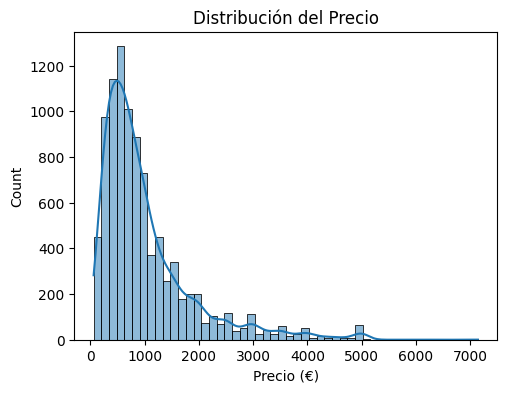

In [5]:
# Distribución del precio
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['price'], bins=50, kde=True)
plt.title('Distribución del Precio')
plt.xlabel('Precio (€)')

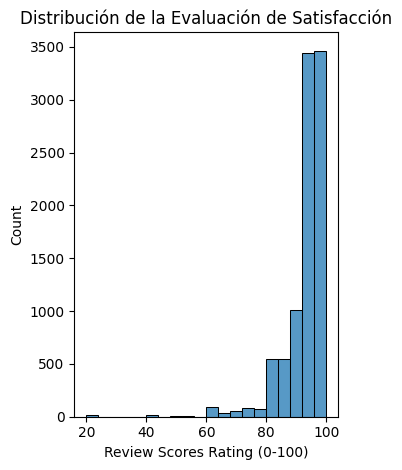

In [6]:
# Distribución de la evaluación
plt.subplot(1, 2, 2)
sns.histplot(df_clean['review_scores_rating'], bins=20, kde=False)
plt.title('Distribución de la Evaluación de Satisfacción')
plt.xlabel('Review Scores Rating (0-100)')
plt.tight_layout()
plt.show()

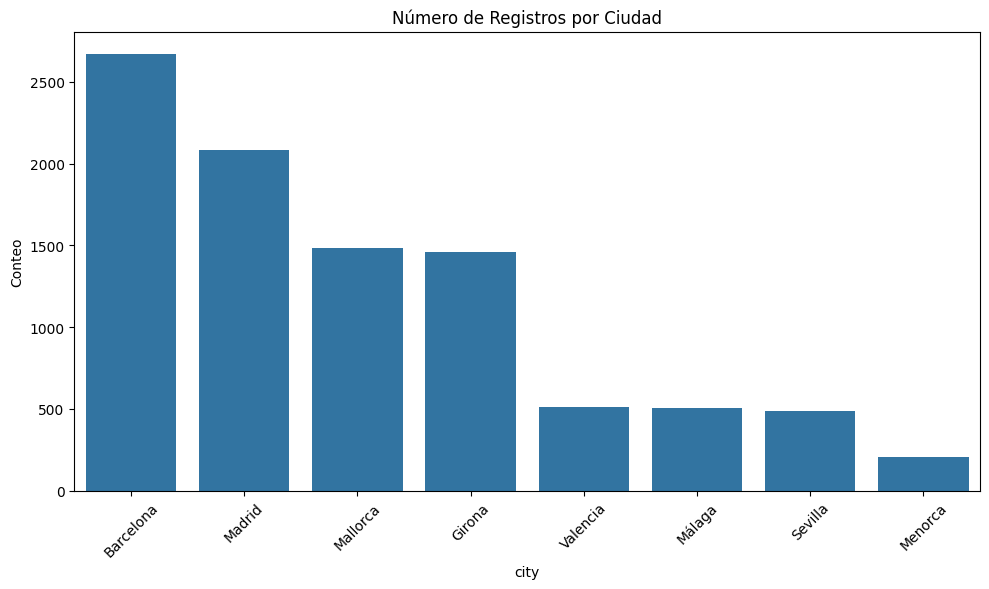


Conteo de registros por ciudad:
city
Barcelona    2673
Madrid       2083
Mallorca     1485
Girona       1459
Valencia      510
Málaga        503
Sevilla       486
Menorca       207
Name: count, dtype: int64


In [7]:
# Conteo de registros por ciudad
plt.figure(figsize=(10, 6))
city_counts = df_clean['city'].value_counts()
sns.barplot(x=city_counts.index, y=city_counts.values)
plt.title('Número de Registros por Ciudad')
plt.xticks(rotation=45)
plt.ylabel('Conteo')
plt.tight_layout()
plt.show()
print("\nConteo de registros por ciudad:")
print(city_counts)

# Análisis de la Relación General (Precio vs. Satisfacción)


Correlación de Pearson entre Precio y Evaluación (General): 0.0699


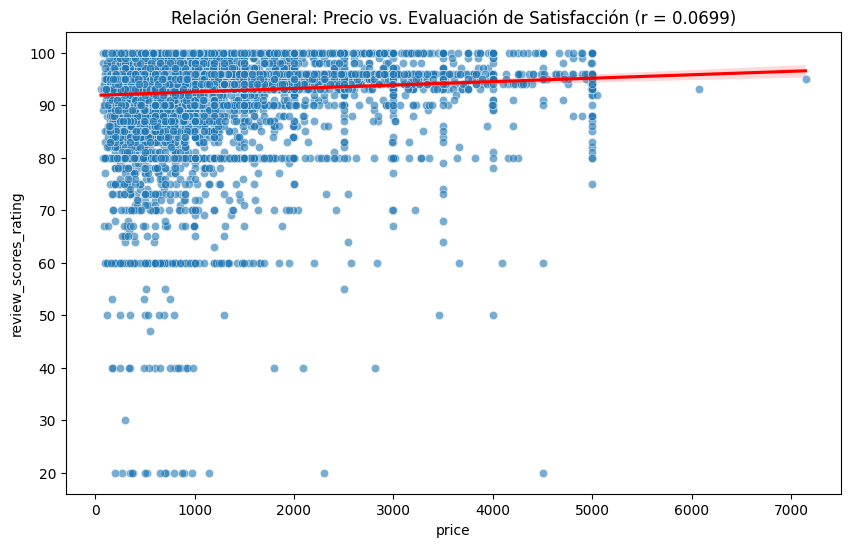

In [8]:
# Calcular correlación de Pearson
correlation_general = df_clean['price'].corr(df_clean['review_scores_rating'])
print(f"\nCorrelación de Pearson entre Precio y Evaluación (General): {correlation_general:.4f}")

# Gráfico de dispersión general
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='price', y='review_scores_rating', alpha=0.6)
plt.title(f'Relación General: Precio vs. Evaluación de Satisfacción (r = {correlation_general:.4f})')
plt.xlabel('Precio (€)')
plt.ylabel('Evaluación de Satisfacción (0-100)')

# Agregar línea de regresión
sns.regplot(data=df_clean, x='price', y='review_scores_rating', scatter=False, color='red')
plt.show()

# Análisis de la Relación por Ciudad


Correlación entre Precio y Evaluación por Ciudad:
        city  correlation
0  Barcelona    -0.035707
1     Girona     0.102126
2     Madrid     0.056348
3   Mallorca     0.095392
4    Menorca     0.098281
5     Málaga     0.105396
6    Sevilla     0.019389
7   Valencia     0.044276


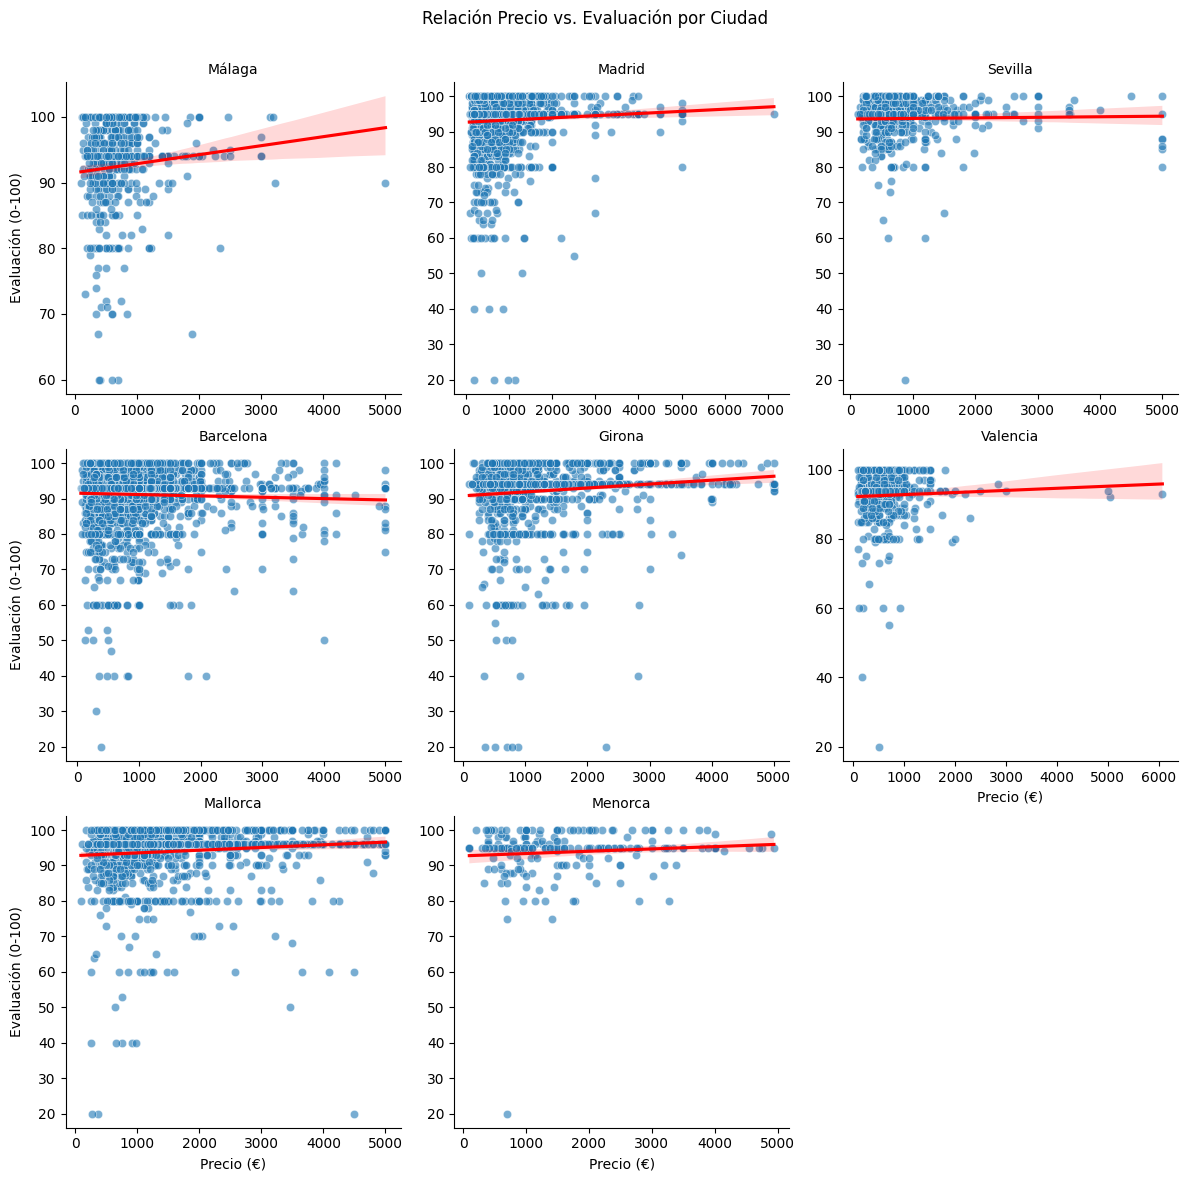

In [9]:
# Calcular correlación por ciudad
correlations_by_city = df_clean.groupby('city').apply(lambda x: x['price'].corr(x['review_scores_rating'])).reset_index()
correlations_by_city.columns = ['city', 'correlation']
print("\nCorrelación entre Precio y Evaluación por Ciudad:")
print(correlations_by_city)

# Gráfico de dispersión facetado por ciudad
# Usando FacetGrid de Seaborn
g = sns.FacetGrid(df_clean, col='city', col_wrap=3, height=4, sharex=False, sharey=False)
g.map(sns.scatterplot, 'price', 'review_scores_rating', alpha=0.6)
g.map(sns.regplot, 'price', 'review_scores_rating', scatter=False, color='red')
g.set_axis_labels('Precio (€)', 'Evaluación (0-100)')
g.set_titles('{col_name}')
plt.subplots_adjust(top=0.92)
g.fig.suptitle('Relación Precio vs. Evaluación por Ciudad')
plt.show()

In [12]:
# Preparar los datos para statsmodels (agregando constante)
# df_for_regression = df_clean[['price', 'city', 'review_scores_rating']].copy()
# model_interaction = ols('review_scores_rating ~ price * C(city)', data=df_for_regression).fit()

# Alternativamente, usando statsmodels directamente con fórmula:
# La interacción es representada por price:C(city)
formula_interaction = 'review_scores_rating ~ price * C(city)'
model_interaction = ols(formula_interaction, data=df_clean).fit()

print("\nResumen de la Regresión con Interacción (Precio * Ciudad):")
print(model_interaction.summary())

# Interpretar los coeficientes de interacción es complejo.
# Una abordaje más práctica es correr regresiones separadas por ciudad o usar contrastes.
# Vamos a intentar una regresión simple de precio por ciudad y plotear los coeficientes.


Resumen de la Regresión con Interacción (Precio * Ciudad):
                             OLS Regression Results                             
Dep. Variable:     review_scores_rating   R-squared:                       0.022
Model:                              OLS   Adj. R-squared:                  0.020
Method:                   Least Squares   F-statistic:                     13.87
Date:                  Wed, 12 Nov 2025   Prob (F-statistic):           1.35e-35
Time:                          17:37:15   Log-Likelihood:                -32903.
No. Observations:                  9406   AIC:                         6.584e+04
Df Residuals:                      9390   BIC:                         6.595e+04
Df Model:                            15                                         
Covariance Type:              nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------


Coeficiente de Precio y P-Valor por Ciudad (de la regresión simple):
        city     slope   p_value
0  Barcelona -0.000382  0.064918
1     Girona  0.001106  0.000093
2     Madrid  0.000613  0.010105
3   Mallorca  0.000761  0.000232
4    Menorca  0.000652  0.158875
5     Málaga  0.001372  0.018054
6    Sevilla  0.000158  0.669839
7   Valencia  0.000611  0.318314


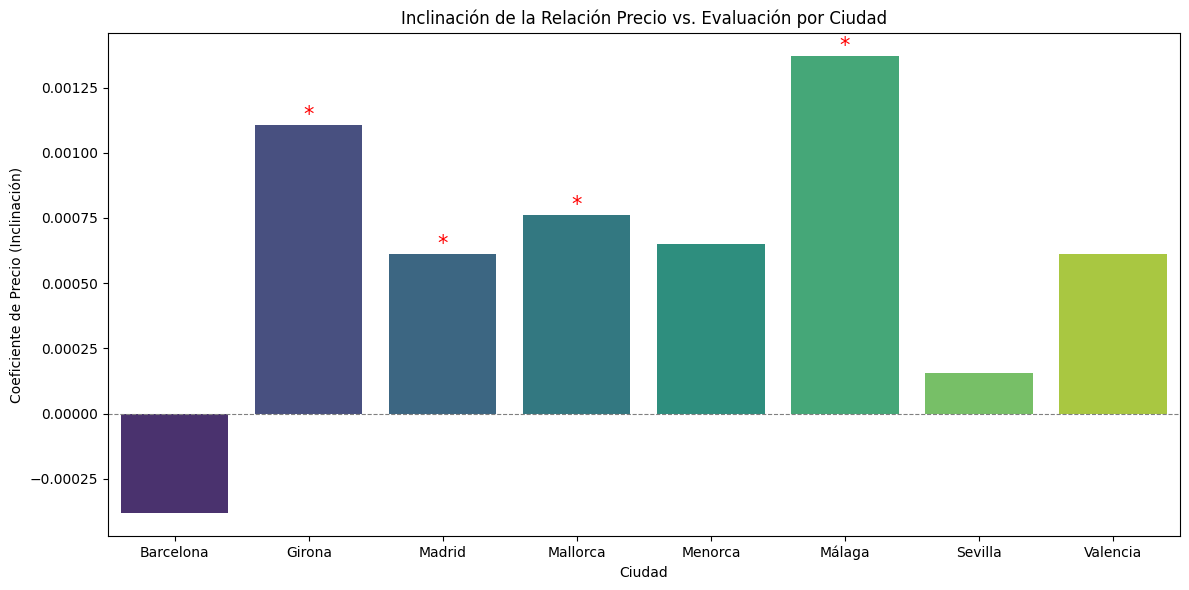

In [20]:
# Función para calcular la regresión lineal simple y retornar el coeficiente de precio y p-valor
def get_price_coef_and_pval(group):
    if len(group) < 2: # Necesario al menos 2 puntos para regresión
        return pd.Series({'slope': np.nan, 'p_value': np.nan})
    y = group['review_scores_rating']
    X = group['price']
    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const).fit()
    slope = model.params['price']
    p_val = model.pvalues['price']
    return pd.Series({'slope': slope, 'p_value': p_val})

# Aplicar la función a cada grupo de ciudad
city_results = df_clean.groupby('city').apply(get_price_coef_and_pval).reset_index()

print("\nCoeficiente de Precio y P-Valor por Ciudad (de la regresión simple):")
print(city_results)

# Gráfico de barras de los coeficientes de inclinación
plt.figure(figsize=(12, 6))
bars = sns.barplot(data=city_results, x='city', y='slope', palette='viridis')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Línea horizontal en 0
plt.title('Inclinación de la Relación Precio vs. Evaluación por Ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Coeficiente de Precio (Inclinación)')

# Agregar anotaciones de significancia (opcional)
for index, row in city_results.iterrows():
    if not pd.isna(row['p_value']) and row['p_value'] < 0.05:
        plt.text(index, row['slope'], '*', ha='center', va='bottom', fontsize=15, color='red')

plt.tight_layout()
plt.show()


Correlación de Spearman entre Precio y Evaluación (General): 0.1127


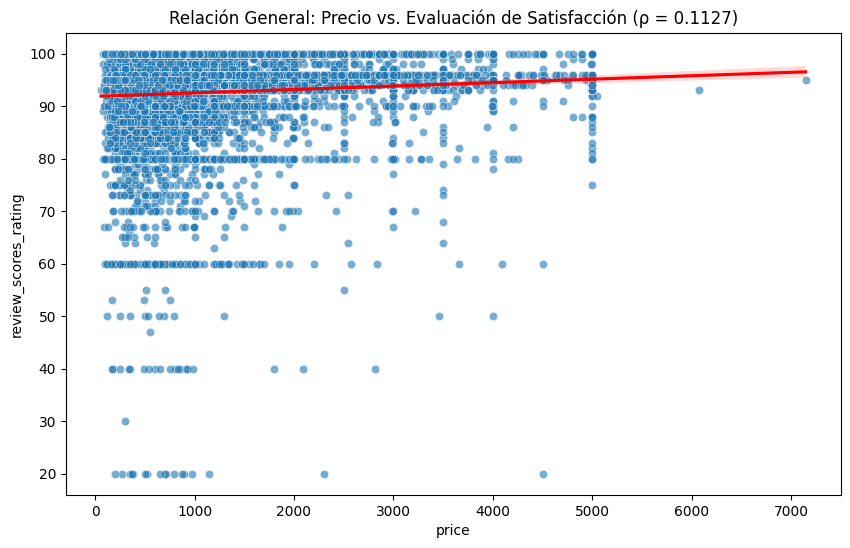

In [14]:
# Análisis de la Relación General (Precio vs. Satisfacción)
# Esta acción calcula la correlación de Spearman entre precio y evaluación para todos los datos y crea un gráfico de dispersión general.
correlation_general = df_clean['price'].corr(df_clean['review_scores_rating'], method='spearman')
print(f"\nCorrelación de Spearman entre Precio y Evaluación (General): {correlation_general:.4f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='price', y='review_scores_rating', alpha=0.6)
plt.title(f'Relación General: Precio vs. Evaluación de Satisfacción (ρ = {correlation_general:.4f})')
plt.xlabel('Precio (€)')
plt.ylabel('Evaluación de Satisfacción (0-100)')

sns.regplot(data=df_clean, x='price', y='review_scores_rating', scatter=False, color='red')
plt.show()


Correlación de Spearman entre Precio y Evaluación por Ciudad:
        city  spearman_correlation
0  Barcelona             -0.044391
1     Girona              0.130911
2     Madrid              0.062376
3   Mallorca              0.144250
4    Menorca              0.028974
5     Málaga              0.146747
6    Sevilla              0.072713
7   Valencia              0.071469


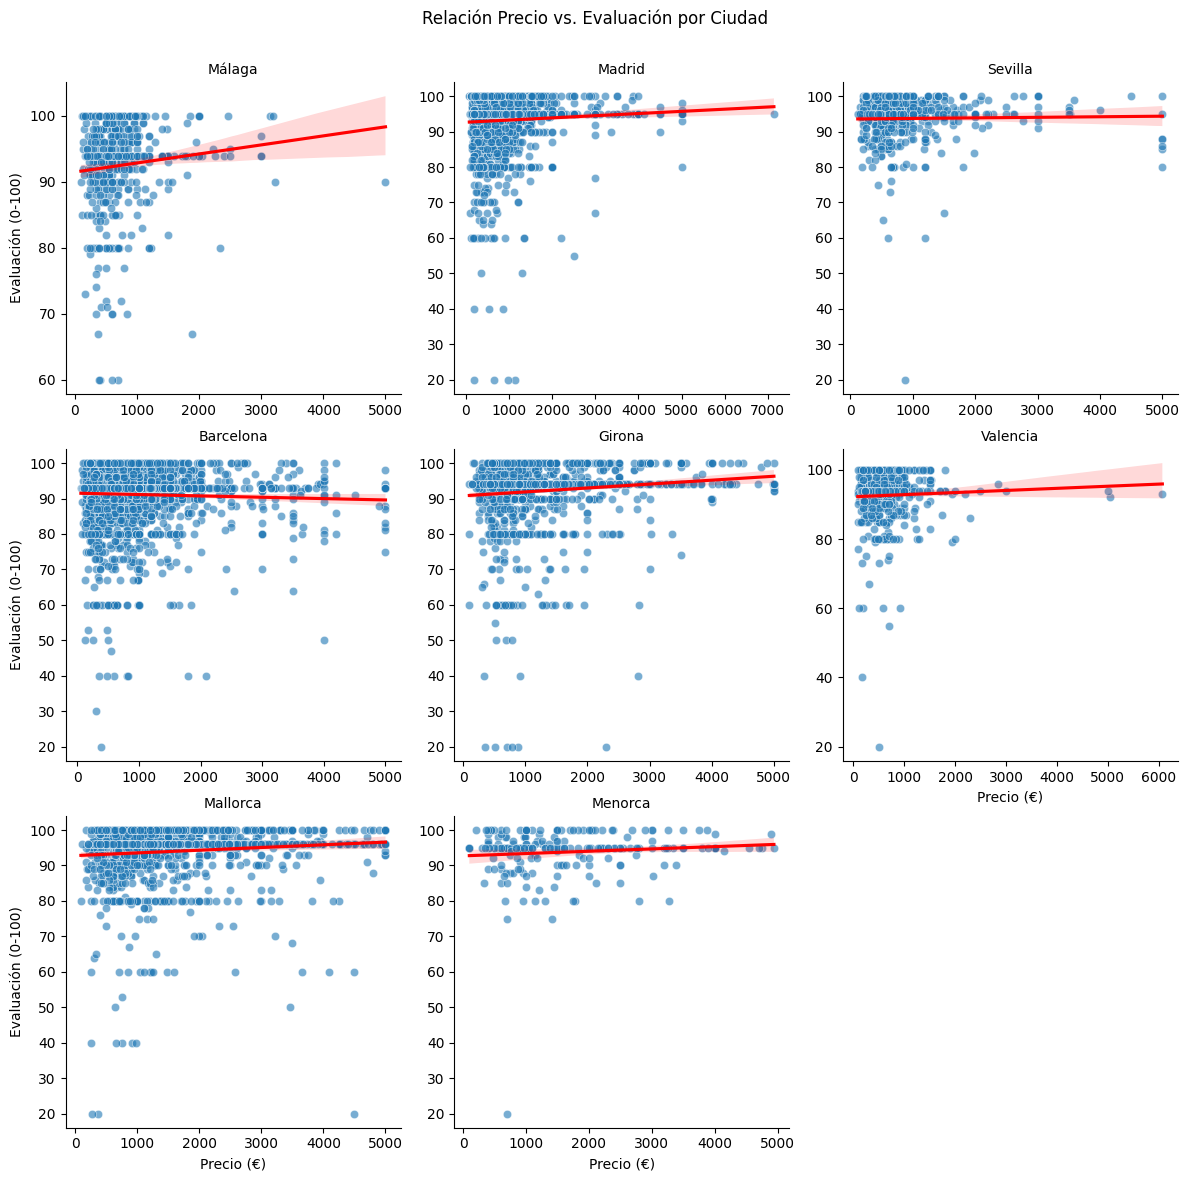

In [15]:
# Análisis de la Relación por Ciudad
# Esta acción calcula la correlación de Spearman entre precio y evaluación para cada ciudad y crea gráficos de dispersión facetados por ciudad.
correlations_by_city = df_clean.groupby('city').apply(lambda x: x['price'].corr(x['review_scores_rating'], method='spearman')).reset_index()
correlations_by_city.columns = ['city', 'spearman_correlation']
print("\nCorrelación de Spearman entre Precio y Evaluación por Ciudad:")
print(correlations_by_city)

g = sns.FacetGrid(df_clean, col='city', col_wrap=3, height=4, sharex=False, sharey=False)
g.map(sns.scatterplot, 'price', 'review_scores_rating', alpha=0.6)
g.map(sns.regplot, 'price', 'review_scores_rating', scatter=False, color='red')
g.set_axis_labels('Precio (€)', 'Evaluación (0-100)')
g.set_titles('{col_name}')
plt.subplots_adjust(top=0.92)
g.fig.suptitle('Relación Precio vs. Evaluación por Ciudad')
plt.show()

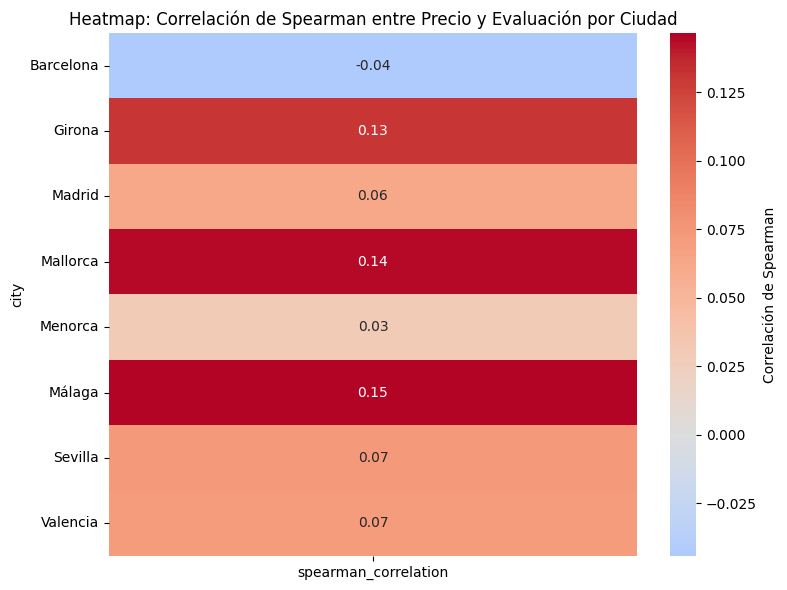

In [ ]:
# --- Nuevo Paso: Heatmap de Correlación por Ciudad ---
# Esta acción crea un heatmap para visualizar la correlación de Spearman entre precio y evaluación para cada ciudad.
# Primero, creamos un DataFrame pivoteado si quisiéramos comparar con otras variables.
# Pero para correlación simple, usamos la serie ya calculada.
# Creamos un DataFrame auxiliar para el heatmap.
heatmap_data = correlations_by_city.set_index('city')['spearman_correlation'].to_frame()

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', center=0, fmt='.2f', cbar_kws={'label': 'Correlación de Spearman'})
plt.title('Heatmap: Correlación de Spearman entre Precio y Evaluación por Ciudad')
plt.tight_layout()
plt.show()

In [17]:
# Regresión Lineal con Interacción (Precio * Ciudad)
# Esta acción ajusta un modelo de regresión lineal que incluye la interacción entre precio y ciudad.
# Esto permite evaluar si la relación entre precio y evaluación varía significativamente entre ciudades.
formula_interaction = 'review_scores_rating ~ price * C(city)'
model_interaction = ols(formula_interaction, data=df_clean).fit()

print("\nResumen de la Regresión con Interacción (Precio * Ciudad):")
print(model_interaction.summary())


Resumen de la Regresión con Interacción (Precio * Ciudad):
                             OLS Regression Results                             
Dep. Variable:     review_scores_rating   R-squared:                       0.022
Model:                              OLS   Adj. R-squared:                  0.020
Method:                   Least Squares   F-statistic:                     13.87
Date:                  Wed, 12 Nov 2025   Prob (F-statistic):           1.35e-35
Time:                          17:46:39   Log-Likelihood:                -32903.
No. Observations:                  9406   AIC:                         6.584e+04
Df Residuals:                      9390   BIC:                         6.595e+04
Df Model:                            15                                         
Covariance Type:              nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------


Coeficiente de Precio y P-Valor por Ciudad (de la regresión simple):
        city     slope   p_value
0  Barcelona -0.000382  0.064918
1     Girona  0.001106  0.000093
2     Madrid  0.000613  0.010105
3   Mallorca  0.000761  0.000232
4    Menorca  0.000652  0.158875
5     Málaga  0.001372  0.018054
6    Sevilla  0.000158  0.669839
7   Valencia  0.000611  0.318314


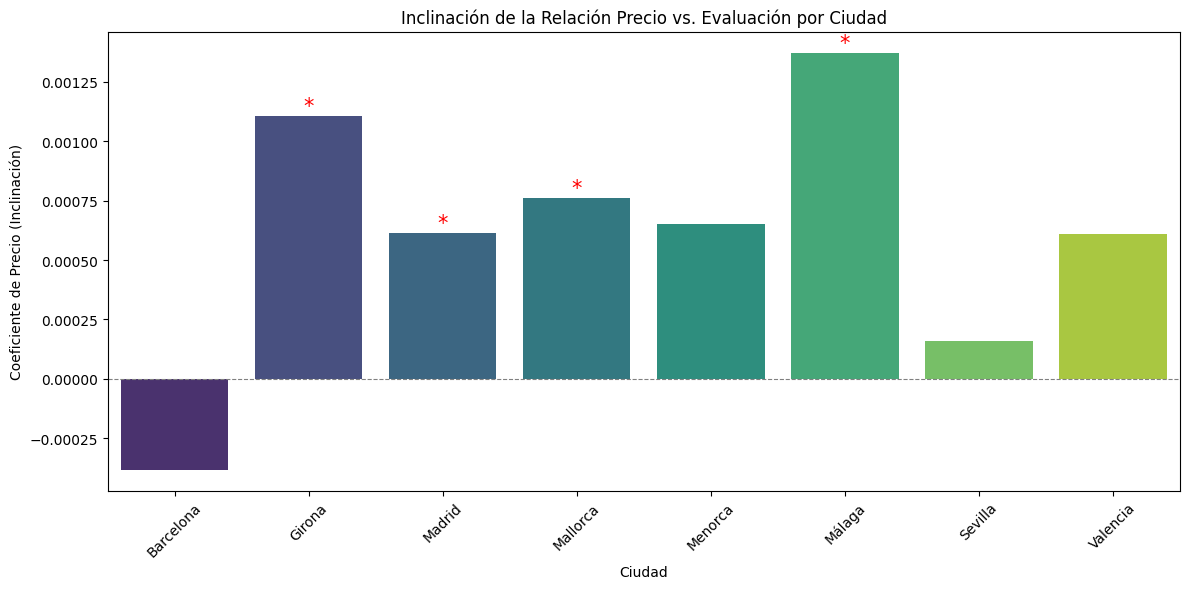

In [18]:
# Regresiones Simples por Ciudad (Alternativa a la Interacción)
# Esta acción ajusta una regresión lineal simple (solo precio) para cada ciudad y extrae el coeficiente de pendiente (inclinación de la relación precio-evaluación).
def get_price_coef_and_pval(group):
    # Esta función calcula la regresión lineal simple y retorna el coeficiente de precio y p-valor para un grupo de datos.
    if len(group) < 2: # Necesario al menos 2 puntos para regresión
        return pd.Series({'slope': np.nan, 'p_value': np.nan})
    y = group['review_scores_rating']
    X = group['price']
    X_with_const = sm.add_constant(X)
    model = sm.OLS(y, X_with_const).fit()
    slope = model.params['price']
    p_val = model.pvalues['price']
    return pd.Series({'slope': slope, 'p_value': p_val})

city_results = df_clean.groupby('city').apply(get_price_coef_and_pval).reset_index()

print("\nCoeficiente de Precio y P-Valor por Ciudad (de la regresión simple):")
print(city_results)

plt.figure(figsize=(12, 6))
bars = sns.barplot(data=city_results, x='city', y='slope', palette='viridis')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Línea horizontal en 0
plt.title('Inclinación de la Relación Precio vs. Evaluación por Ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Coeficiente de Precio (Inclinación)')
plt.xticks(rotation=45)

# Agregar anotaciones de significancia (opcional)
for index, row in city_results.iterrows():
    if not pd.isna(row['p_value']) and row['p_value'] < 0.05:
        plt.text(index, row['slope'], '*', ha='center', va='bottom', fontsize=15, color='red')

plt.tight_layout()
plt.show()